# Notes

In [1082]:
'''
    Look at what you have, RI2, RI1, recordings, and behaviors.
    Think about what quesitons you want to answer with this data.
    consider the following:
        # 1. What are the most common behaviors leading to fighting?
        # 2. What are the latencies of these behaviors?
        # 3. How do these latencies differ between subject and agent roles?
        # 4. Are there any significant differences in latencies between different behaviors?
        # 5. How do latencies change over time or across different recordings?
        # 6. Are there any outliers in the latencies that need to be addressed?
        # 7. How do the latencies compare to the maximum latency threshold?
        # 8. What is the distribution of latencies for each behavior?
        # 9. How do the latencies of subject behaviors compare to agent behaviors?
        # 10. Are there any trends or patterns in the latencies that can be observed?
    
    Then thinking about the respiratory data, consider:
        # 1. How do respiratory rate change before and after fighting events?
        # 2. Do certain behaviors correlate with changes in respiratory rate?
        # 3. Are there any significant differences in respiratory rate between subject and agent roles?
        # 4. How does the respiratory rate change over time or across different recordings?


    To answer all these questions think about how the data must be filtered to answer each question. Maybe questions 1-3 can be answered with the same data, 
    but question 4 might require a different filter.

    Find which ones you want to answer the most and think through how to filter the data to answer those questions.

    example plot is on cohort1_hzchange at root
    Ask ai other plots used to find the questions you want to answer.
'''


'\n    Look at what you have, RI2, RI1, recordings, and behaviors.\n    Think about what quesitons you want to answer with this data.\n    consider the following:\n        # 1. What are the most common behaviors leading to fighting?\n        # 2. What are the latencies of these behaviors?\n        # 3. How do these latencies differ between subject and agent roles?\n        # 4. Are there any significant differences in latencies between different behaviors?\n        # 5. How do latencies change over time or across different recordings?\n        # 6. Are there any outliers in the latencies that need to be addressed?\n        # 7. How do the latencies compare to the maximum latency threshold?\n        # 8. What is the distribution of latencies for each behavior?\n        # 9. How do the latencies of subject behaviors compare to agent behaviors?\n        # 10. Are there any trends or patterns in the latencies that can be observed?\n\n    Then thinking about the respiratory data, consider:\

In [1083]:
'''
    I have at the end of this dicts with the following structure:
    {
        'recording': recording_name,
        'from_behavior': behavior,
        'to_behavior': target_behavior,
        'latency': latency,
        'prior_stop_time': closest_stop,  # closest stop time before the target start
        'target_start_time': target_start,  # target start time of the fighting event
        'behavior_start_time': behavior_start_time,  # start time of the behavior that led to the fight
        'from_role': from_role,
        'to_role': to_role
    }

    I can load in the respiratory data and filter it by the recording name, then I can use the 'behavior_start_time' to 
    find the respiratory data before the start time, at at a duration I choose, and after the start time. Finding the 
    difference in breathing rate before and after the start time.
    
    I can then plot the respiratory rate change before and after the start time for each behavior that led to a fight.
'''

"\n    I have at the end of this dicts with the following structure:\n    {\n        'recording': recording_name,\n        'from_behavior': behavior,\n        'to_behavior': target_behavior,\n        'latency': latency,\n        'prior_stop_time': closest_stop,  # closest stop time before the target start\n        'target_start_time': target_start,  # target start time of the fighting event\n        'behavior_start_time': behavior_start_time,  # start time of the behavior that led to the fight\n        'from_role': from_role,\n        'to_role': to_role\n    }\n\n    I can load in the respiratory data and filter it by the recording name, then I can use the 'behavior_start_time' to \n    find the respiratory data before the start time, at at a duration I choose, and after the start time. Finding the \n    difference in breathing rate before and after the start time.\n\n    I can then plot the respiratory rate change before and after the start time for each behavior that led to a fight.\

In [1084]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk
import rsp.data_processing.signal_processing as signal_processing
from rsp.plotting import Rsp_Kit
import seaborn as sns

import importlib
importlib.reload(signal_processing)
importlib.reload(Rsp_Kit)

<module 'rsp.plotting.Rsp_Kit' from 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\src\\rsp\\plotting\\Rsp_Kit.py'>

In [1085]:
pd.set_option('display.max_colwidth', 0)  # 0 means unlimited in newer pandas versions

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column contents
pd.set_option("display.max_colwidth", None)

# Expand the display to the full width of the screen
pd.set_option("display.width", 0)


In [1086]:
# path of folder containing all boris/behavioral data
root_boris = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\Data\behavior_aim1"

In [1087]:
# root path of the respiratory data h5 files
root_resp = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5"

### Loading and Cleaning Resp Signals Function

In [1088]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

### Loading the resp signals with function

In [1089]:

# Collect all .h5 file paths in the directory
h5_files = [f for f in os.listdir(root_resp) if f.endswith(".h5")]

# Create a dictionary to store results
resp_data = {}

# Loop through each file and process
for filename in h5_files:
    full_path = os.path.join(root_resp, filename)
    label = os.path.splitext(filename)[0]  # remove .h5 extension
    print(f"Processing {label}...")
    
    signal, time, rate = load_clean_resp_signal(full_path)
    
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("All available signals loaded.")

Processing BLRI_s1_1_p5_2_nRB6_20250622_141846_merged...
Processing BLRI_s1_2_p5_1_nRB6_20250622_164833_merged...
Processing BLRI_s2_3_p5_3_nRB3_20250622_101813_merged...
Processing BLRI_s2_4_p5_4_nRB3_20250622_121708_merged...
Processing BLRI_s3_6_p5_3_nRB3_20250621_123634_merged...
Processing BLRI_s4_7_p5_2_nRB3_20250621_144806_merged...
Processing BLRI_s4_8_p5_1_nRB3_20250621_163506_merged...
Processing BLRI_s5_13_p5_4_nRB3_20250622_175809_merged...
Error loading C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5\BLRI_s5_13_p5_4_nRB3_20250622_175809_merged.h5: "Unable to synchronously open object (object 'resp' doesn't exist)"
Skipping BLRI_s5_13_p5_4_nRB3_20250622_175809_merged: failed to load.
Processing RI1_s1_1_p5_2_nRB6_20250622_143958_merged...
Processing RI1_s1_2_p5_1_nRB6_20250622_170742_merged...
Processing RI1_s2_3_p5_3_nRB3_20250622_104059_merged...
Error loading C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\upd

### Quick Plot to see if it worked

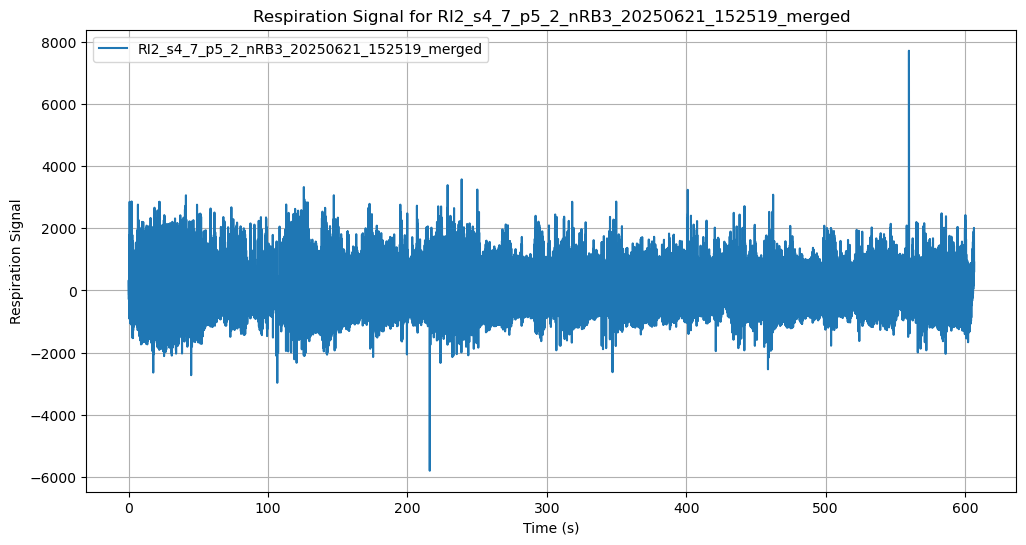

In [1090]:
# checking if the resp_data dictionary is populated
def plot_resp_signal(label, resp_data):
    """
    Plots the respiration signal for a given label.
    """
    if label not in resp_data:
        print(f"No data found for {label}.")
        return
    
    data = resp_data[label]
    plt.figure(figsize=(12, 6))
    plt.plot(data['time'], data['signal'], label=label)
    plt.title(f"Respiration Signal for {label}")
    plt.xlabel("Time (s)")
    plt.ylabel("Respiration Signal")
    plt.legend()
    plt.grid()
    plt.show()

# Example usage
plot_resp_signal('RI2_s4_7_p5_2_nRB3_20250621_152519_merged', resp_data)

#### Unecessary but making sure messed up recs are excluded

In [1091]:
# exclude certain recordings such as BLRI_s5_13_p5_4_nRB3_20250622_175809_merged.h5 and RI1_s2_3_p5_3_nRB3_20250622_104059_merged.h5
# Define the recordings to exclude
excluded_recordings_recs = [
    'BLRI_s5_13_p5_4_nRB3_20250622_175809_merged',
    'RI1_s2_3_p5_3_nRB3_20250622_104059_merged',
    'RI1_s2_3_p5_3_nRB3_20250622_104059.2_merged',
    'RI1_s5_13_p5_4_nRB3_20250622_181801_merged',
    'RI2_s5_13_p5_4_nRB3_20250622_184136_merged',
]
# Filter out the excluded recordings from the resp_data dictionary
for recording in excluded_recordings_recs:
    if recording in resp_data:
        del resp_data[recording]
        print(f"Excluded {recording} from respiratory data.")

Excluded RI1_s5_13_p5_4_nRB3_20250622_181801_merged from respiratory data.
Excluded RI2_s5_13_p5_4_nRB3_20250622_184136_merged from respiratory data.


In [1092]:
# print all recording names in resp_data
print("Remaining recordings in respiratory data:")
for recording in resp_data.keys():
    print(recording)

Remaining recordings in respiratory data:
BLRI_s1_1_p5_2_nRB6_20250622_141846_merged
BLRI_s1_2_p5_1_nRB6_20250622_164833_merged
BLRI_s2_3_p5_3_nRB3_20250622_101813_merged
BLRI_s2_4_p5_4_nRB3_20250622_121708_merged
BLRI_s3_6_p5_3_nRB3_20250621_123634_merged
BLRI_s4_7_p5_2_nRB3_20250621_144806_merged
BLRI_s4_8_p5_1_nRB3_20250621_163506_merged
RI1_s1_1_p5_2_nRB6_20250622_143958_merged
RI1_s1_2_p5_1_nRB6_20250622_170742_merged
RI1_s2_4_p5_4_nRB3_20250622_123424_merged
RI1_s3_5_p5_4_nRB3_20250621_105014_merged
RI1_s3_6_p5_3_nRB3_20250621_125312_merged
RI1_s4_7_p5_2_nRB3_20250621_150707_merged
RI1_s4_8_p5_1_nRB3_20250621_165214_merged
RI2_s1_1_p5_2_nRB6_20250622_150457_merged
RI2_s1_2_p5_1_nRB6_20250622_173049_merged
RI2_s2_3_p5_3_nRB3_20250622_110216_merged
RI2_s2_4_p5_4_nRB3_20250622_125648_merged
RI2_s3_5_p5_4_nRB3_20250621_112618_merged
RI2_s4_7_p5_2_nRB3_20250621_152519_merged
RI2_s4_8_p5_1_nRB3_20250621_171318_merged


### Making the dataframe that has all the boris files so I can start filtering and extracting for latencies

In [1093]:
# messed up resp recs
excluded_recordings_boris_csv = [
    'BLRI_s5_13_p5_4_nRB3_20250622_175809.1.csv',
    'RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv',
    'BLRI_s5_13_p5_4_nRB3_20250622_175809.2.csv',
    'RI1_s2_3_p5_3_nRB3_20250622_104059.2.csv',
    'RI1_s5_13_p5_4_nRB3_20250622_181801.1.csv',
    'RI1_s5_13_p5_4_nRB3_20250622_181801.2.csv',
    'RI2_s5_13_p5_4_nRB3_20250622_184136.1.csv',
    'RI2_s5_13_p5_4_nRB3_20250622_184136.2.csv',
]

# Creating dataframe with all boris files, skipping excluded files
boris_files = [os.path.join(root_boris, f) for f in os.listdir(root_boris) if f.endswith('.csv') and f not in excluded_recordings_boris_csv]
boris_df = pd.DataFrame()
for file in boris_files:
    temp_df = pd.read_csv(file)
    boris_df = pd.concat([boris_df, temp_df], ignore_index=True)

boris_df.head()

,Observation id,Observation date,Description,Media file,Total length,FPS,Subject,Behavior,Behavioral category,Modifiers,Behavior type,Start (s),Stop (s),Duration (s),Comment start,Comment stop,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Observation duration by subject by observation,Media file name,Image index start,Image index stop,Image file path start,Image file path stop
0,RI1_s1_1_p5_2_nRB6_20250622_143958.1,2025-07-03 10:47:38,NaN,/Users/ayushjain/Downloads/RI1_s1_1_p5_2_nRB6_20250622_143958.1.mov,715.39,13.0,subject,body sniffing,NaN,NaN,STATE,6.846,11.077,4.231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RI1_s1_1_p5_2_nRB6_20250622_143958.1,2025-07-03 10:47:38,NaN,/Users/ayushjain/Downloads/RI1_s1_1_p5_2_nRB6_20250622_143958.1.mov,715.39,13.0,subject,anogenital sniffing,NaN,NaN,STATE,13.231,17.154,3.923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RI1_s1_1_p5_2_nRB6_20250622_143958.1,2025-07-03 10:47:38,NaN,/Users/ayushjain/Downloads/RI1_s1_1_p5_2_nRB6_20250622_143958.1.mov,715.39,13.0,subject,body sniffing,NaN,NaN,STATE,17.385,28.385,11.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RI1_s1_1_p5_2_nRB6_20250622_143958.1,2025-07-03 10:47:38,NaN,/Users/ayushjain/Downloads/RI1_s1_1_p5_2_nRB6_20250622_143958.1.mov,715.39,13.0,subject,body sniffing,NaN,NaN,STATE,29.538,33.769,4.231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RI1_s1_1_p5_2_nRB6_20250622_143958.1,2025-07-03 10:47:38,NaN,/Users/ayushjain/Downloads/RI1_s1_1_p5_2_nRB6_20250622_143958.1.mov,715.39,13.0,subject,anogenital sniffing,NaN,NaN,STATE,36.231,37.462,1.231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1094]:
print(boris_files)

['C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\Data\\behavior_aim1\\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv', 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\Data\\behavior_aim1\\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv', 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\Data\\behavior_aim1\\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv', 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\Data\\behavior_aim1\\RI1_s3_6_p5_3_nRB3_HEEPS.csv', 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\Data\\behavior_aim1\\RI1_s4_7_p5_2_nRB3_HEEPS.csv', 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\Data\\behavior_aim1\\RI1_s4_8_p5_1_nRB3_HEEPS.csv', 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\Data\\behavior_aim1\\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv', 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\Data\\behavior_aim1\\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv', 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\D

### Creating dictionary of boris recordings and their dataframes to filter for recordings seperately

In [1095]:
# Creating dictionary of dataframes per recording, will help with filtering later
boris_dfs = {}
for file in boris_files:
    recording_name = os.path.splitext(os.path.basename(file))[0]
    temp_df = pd.read_csv(file)
    boris_dfs[recording_name] = temp_df


In [1096]:
boris_df_agent = boris_df[boris_df['Subject'] == 'social_agent']
boris_df_subject = boris_df[boris_df['Subject'] == 'subject']

### Function to create dictionary of behavior types and their start, and stop, and duration

In [1097]:
# Function to extract behavior dictionary from dataframe and apply a 300ms filter
def extract_behavior_dict_from_df(df):
    behavior_dict = {}
    for behavior in df['Behavior'].unique():
        subset = df[df['Behavior'] == behavior]
        start = subset['Start (s)'].values
        stop = subset['Stop (s)'].values
        duration = stop - start
        mask = duration >= 0.3  # Apply 300ms filter here
        behavior_dict[behavior] = {
            'start': start[mask],
            'stop': stop[mask],
            'duration': duration[mask]
        }
    return behavior_dict


### Creating dictionaries of behaviors for each recording and their subject, agents, with the start stop times

In [1098]:
# Keep behavior dictionaries per recording and per subject type
behavior_dicts = {}

for recording, df in boris_dfs.items():
    agent_df = df[df['Subject'] == 'social_agent']
    subject_df = df[df['Subject'] == 'subject']
    
    behavior_dicts[recording] = {
        'agent': extract_behavior_dict_from_df(agent_df),
        'subject': extract_behavior_dict_from_df(subject_df)
    }

# now we have a dictionary of behavior dictionaries per recording and per subject type
# it looks like this:
# {
#     'recording_name': {
#         'agent': {
#             'behavior_name': {
#                 'start': np.array([...]),
#                 'stop': np.array([...]),
#                 'duration': np.array([...])
#             }
#         },
#         'subject': {
#             'behavior_name': {
#                 'start': np.array([...]),
#                 'stop': np.array([...]),
#                 'duration': np.array([...])
#             }
#         }
#     }

### Using above dictionaries, we create a more thorough master dataset to analyze

In [1099]:
from collections import defaultdict

# Function to calculate closest prior stop latencies from each behavior to each fighting event
def calculate_latencies_per_recording(behavior_dicts, from_role='subject', to_role='agent', target_behavior='fighting', max_latency_threshold=5.0):
    all_latencies = []
    exclusion_counts = defaultdict(int)  # Tracks how many times each behavior was excluded

    for recording, roles in behavior_dicts.items():
        source_dict = roles[from_role]
        target_dict = roles[to_role]


        if target_behavior not in target_dict or 'start' not in target_dict[target_behavior]:
            continue

        for target_start in target_dict[target_behavior]['start']: # target start time of the fighting event
            for behavior, times in source_dict.items():
                if behavior == target_behavior:
                    continue

                stop_times = np.array(times['stop']) # stop times of the behavior
                prior_stops = stop_times[stop_times < target_start] # filter stop times that are before the target start time

                if len(prior_stops) > 0: # there are prior stops before the target start time prevents IndexError
                    closest_stop = np.max(prior_stops) # closest stop time before the target start time
                    latency = target_start - closest_stop

                    behavior_start_time = np.min(times['start']) if len(times['start']) > 0 else None # start time of the behavior

                    if latency <= max_latency_threshold:
                        all_latencies.append({
                            'recording': recording,
                            'from_behavior': behavior,
                            'to_behavior': target_behavior,
                            'latency': latency, # latency from the behavior stop to the target start time
                            'prior_stop_time': closest_stop, # closest stop time before the target start, should be behavior stop time
                            'target_start_time': target_start, # target start time, should be the start of the fighting event
                            'behavior_start_time': behavior_start_time, # start time of the behavior
                            'from_role': from_role,
                            'to_role': to_role
                        })
                    else: # count the number of behaviors exlcuded due to latency threshold that were facial sniffing behaviors
                        exclusion_counts[behavior] += 1


    # Print out each behavior type and how many times it was excluded
    for behavior, count in exclusion_counts.items():
        if count > 0:
            print(f"{behavior} was excluded {count} times due to latency threshold of {max_latency_threshold} seconds.")

    return all_latencies

In [1100]:
# make data frame with behavior_di

In [1101]:
latency_subj_to_fight = calculate_latencies_per_recording(behavior_dicts, from_role='subject', to_role='agent', max_latency_threshold=300)

anogenital sniffing was excluded 18 times due to latency threshold of 300 seconds.
body sniffing was excluded 24 times due to latency threshold of 300 seconds.
facial sniffing was excluded 38 times due to latency threshold of 300 seconds.
chasing was excluded 4 times due to latency threshold of 300 seconds.


In [1102]:
latency_subj_to_fight = pd.DataFrame(latency_subj_to_fight)
latency_subj_to_fight.head()

,recording,from_behavior,to_behavior,latency,prior_stop_time,target_start_time,behavior_start_time,from_role,to_role
0,RI2_s1_1_p5_2_nRB6_20250622_150457.1,anogenital sniffing,fighting,29.228,10.905,40.133,9.654,subject,agent
1,RI2_s1_1_p5_2_nRB6_20250622_150457.1,body sniffing,fighting,21.311,18.822,40.133,18.322,subject,agent
2,RI2_s1_1_p5_2_nRB6_20250622_150457.1,anogenital sniffing,fighting,123.828,10.905,134.733,9.654,subject,agent
3,RI2_s1_1_p5_2_nRB6_20250622_150457.1,body sniffing,fighting,115.911,18.822,134.733,18.322,subject,agent
4,RI2_s1_1_p5_2_nRB6_20250622_150457.1,anogenital sniffing,fighting,135.228,10.905,146.133,9.654,subject,agent


In [1103]:
latency_agent_to_fight = calculate_latencies_per_recording(behavior_dicts, from_role='agent', to_role='agent', max_latency_threshold=400)

Posturing was excluded 2 times due to latency threshold of 400 seconds.


In [1104]:
df = pd.DataFrame(latency_agent_to_fight)
df.head()

,recording,from_behavior,to_behavior,latency,prior_stop_time,target_start_time,behavior_start_time,from_role,to_role
0,RI2_s1_1_p5_2_nRB6_20250622_150457.1,body sniffing,fighting,0.066,40.067,40.133,11.533,agent,agent
1,RI2_s1_1_p5_2_nRB6_20250622_150457.1,body sniffing,fighting,0.266,134.467,134.733,11.533,agent,agent
2,RI2_s1_1_p5_2_nRB6_20250622_150457.1,facial sniffing,fighting,7.133,127.600,134.733,126.933,agent,agent
3,RI2_s1_1_p5_2_nRB6_20250622_150457.1,body sniffing,fighting,11.666,134.467,146.133,11.533,agent,agent
4,RI2_s1_1_p5_2_nRB6_20250622_150457.1,facial sniffing,fighting,18.533,127.600,146.133,126.933,agent,agent


In [1105]:
print(latency_agent_to_fight)

[{'recording': 'RI2_s1_1_p5_2_nRB6_20250622_150457.1', 'from_behavior': 'body sniffing', 'to_behavior': 'fighting', 'latency': np.float64(0.0660000000000025), 'prior_stop_time': np.float64(40.067), 'target_start_time': np.float64(40.133), 'behavior_start_time': np.float64(11.533), 'from_role': 'agent', 'to_role': 'agent'}, {'recording': 'RI2_s1_1_p5_2_nRB6_20250622_150457.1', 'from_behavior': 'body sniffing', 'to_behavior': 'fighting', 'latency': np.float64(0.26599999999999113), 'prior_stop_time': np.float64(134.467), 'target_start_time': np.float64(134.733), 'behavior_start_time': np.float64(11.533), 'from_role': 'agent', 'to_role': 'agent'}, {'recording': 'RI2_s1_1_p5_2_nRB6_20250622_150457.1', 'from_behavior': 'facial sniffing', 'to_behavior': 'fighting', 'latency': np.float64(7.13300000000001), 'prior_stop_time': np.float64(127.6), 'target_start_time': np.float64(134.733), 'behavior_start_time': np.float64(126.933), 'from_role': 'agent', 'to_role': 'agent'}, {'recording': 'RI2_s1_1

In [1106]:
def plot_mean_latencies(latencies, title="Mean Latency to Target Behavior"):
    df = pd.DataFrame(latencies)
    mean_latencies = df.groupby('from_behavior')['latency'].mean().sort_values()
    
    plt.figure(figsize=(10, 6))
    mean_latencies.plot(kind='bar', color='skyblue')
    plt.ylabel("Mean Latency (s)")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

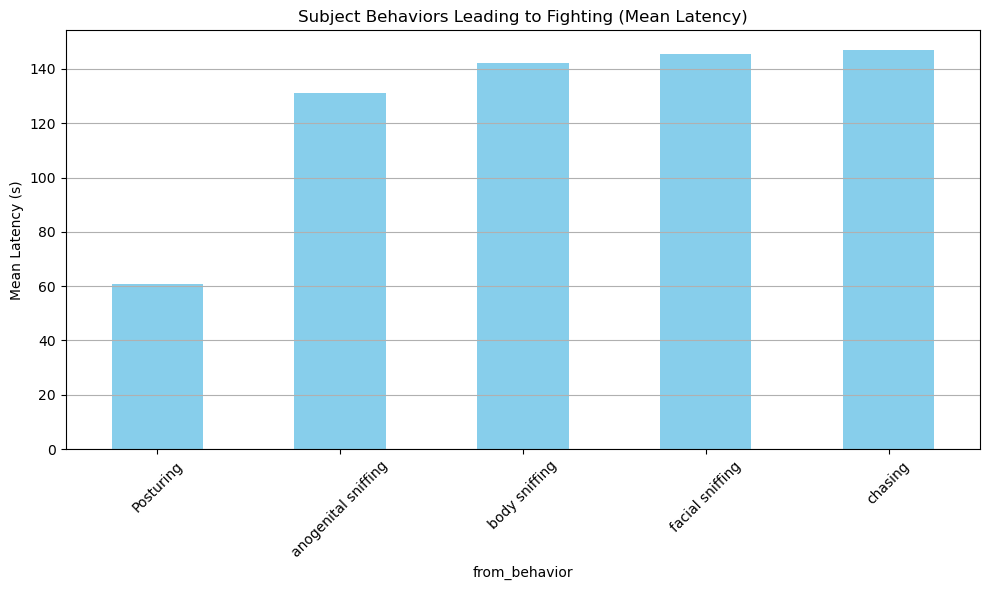

In [1107]:
plot_mean_latencies(latency_subj_to_fight, "Subject Behaviors Leading to Fighting (Mean Latency)")

In [1108]:
def plot_latency_distributions(latencies, title="Latency Distributions by Behavior"):
    df = pd.DataFrame(latencies)
    if df.empty:
        print("No latencies to plot.")
        return

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='from_behavior', y='latency')
    plt.xticks(rotation=45)
    plt.title(title)
    plt.ylabel("Latency (s)")
    plt.xlabel("Behavior Type")
    plt.tight_layout()
    plt.show()


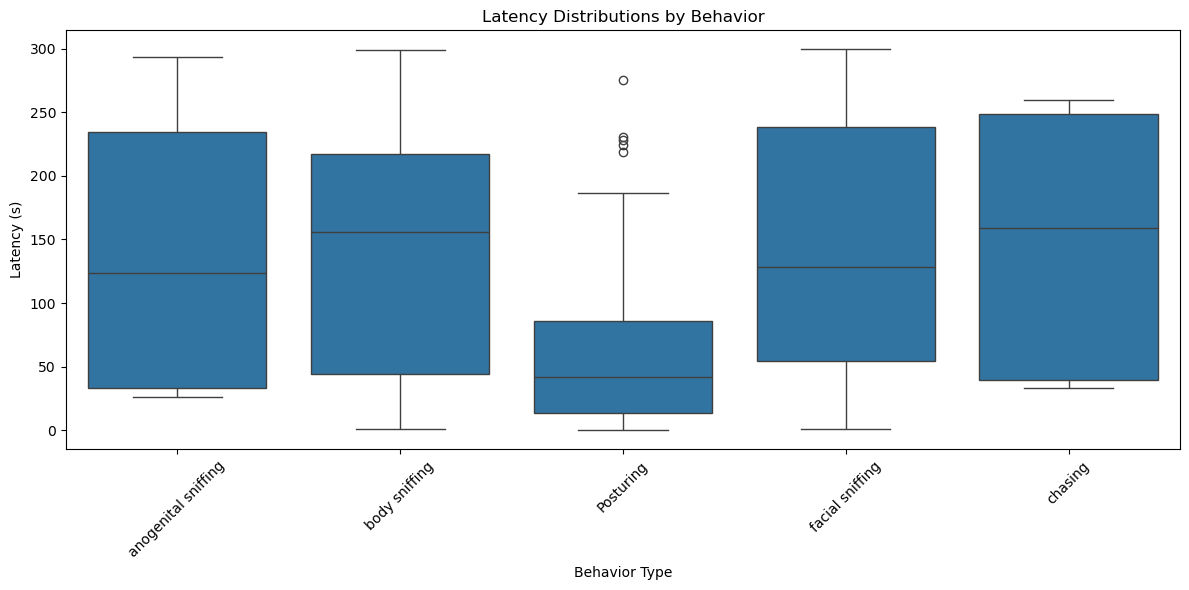

In [1109]:
plot_latency_distributions(latency_subj_to_fight)


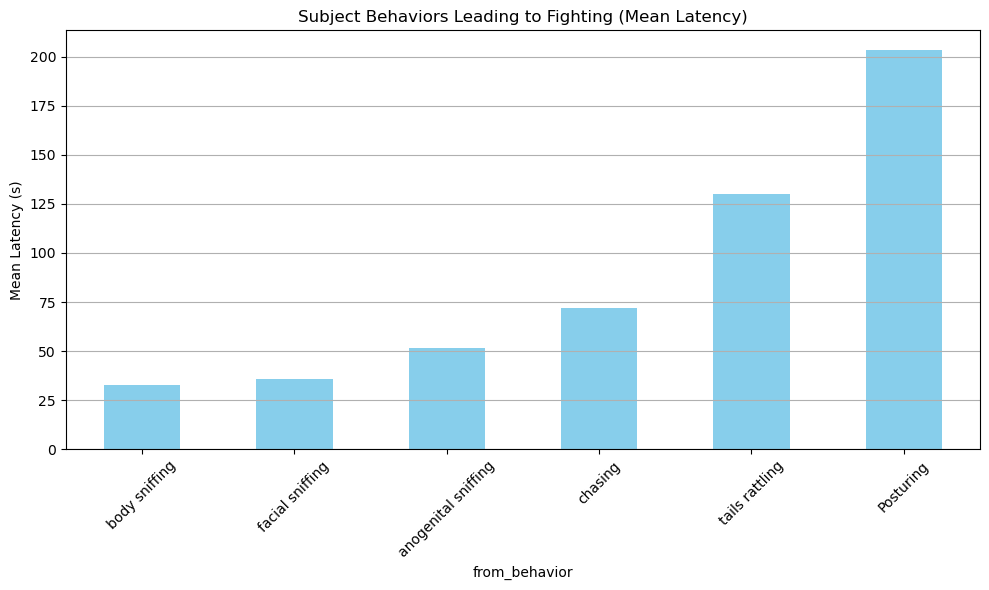

In [1110]:
plot_mean_latencies(latency_agent_to_fight, "Subject Behaviors Leading to Fighting (Mean Latency)")

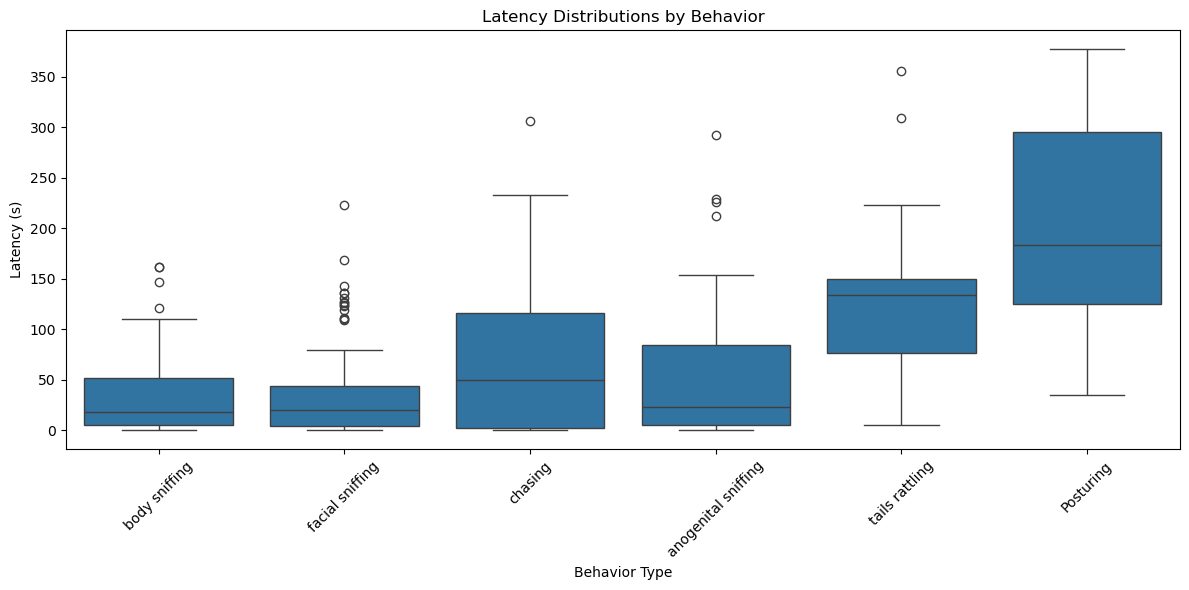

In [1111]:
plot_latency_distributions(latency_agent_to_fight)


### Function from Sequioas cohort1_hzchange notebook to find percent change, we can add to master dataframe

In [1112]:
def get_percent_change_resp_rate(signal, times, sniff_start, sniff_end, sampling_rate=100, baseline_window=4):
    """
    Calculate the percent change in breathing rate during a sniff period 
    relative to a baseline period before the sniff.

    Parameters:
        signal (np.array): 1D respiratory signal array.
        times (np.array): 1D time array aligned with the signal.
        sniff_start (float): Start time of the sniff window.
        sniff_end (float): End time of the sniff window.
        sampling_rate (int): Sampling rate in Hz (default 100).
        baseline_window (float): Duration of baseline window before sniff_start in seconds (default 4).

    Returns:
        float: Percent change in breathing rate during sniff relative to baseline. NaN if invalid.
    """
    baseline_start = sniff_start - baseline_window
    baseline_end = sniff_start

    # Define masks for baseline and sniff periods
    baseline_mask = (times >= baseline_start) & (times < baseline_end)
    sniff_mask = (times >= sniff_start) & (times < sniff_end)

    signal_baseline = signal[baseline_mask]
    signal_sniff = signal[sniff_mask]

    # Safety check: Ensure there is data in both periods
    if signal_baseline.size == 0 or signal_sniff.size == 0:
        return np.nan

    # Detect peaks (breaths) in each period
    min_distance = int(sampling_rate * 0.0833) # 0.0833 seconds corresponds to ~12 Hz
    peaks_baseline, _ = find_peaks(signal_baseline, distance=min_distance)
    peaks_sniff, _ = find_peaks(signal_sniff, distance=min_distance)

    # Calculate duration of each window
    baseline_duration = baseline_end - baseline_start
    sniff_duration = sniff_end - sniff_start

    if baseline_duration <= 0 or sniff_duration <= 0:
        return np.nan

    # Calculate rates (Hz)
    rate_baseline = len(peaks_baseline) / baseline_duration
    rate_sniff = len(peaks_sniff) / sniff_duration

    if rate_baseline == 0 or np.isnan(rate_baseline):
        return np.nan  # avoid divide by zero

    percent_change = ((rate_sniff - rate_baseline) / rate_baseline) * 100

    # Debug info
    # print(f"Baseline rate: {rate_baseline:.2f} Hz, Sniff rate: {rate_sniff:.2f} Hz, % Change: {percent_change:.2f}%")

    return percent_change


#### List of Resp Filenames doesn't match up with entries from behavior dict

In [1113]:
labels = list(resp_data.keys())
print(f"Available labels: {labels}")

Available labels: ['BLRI_s1_1_p5_2_nRB6_20250622_141846_merged', 'BLRI_s1_2_p5_1_nRB6_20250622_164833_merged', 'BLRI_s2_3_p5_3_nRB3_20250622_101813_merged', 'BLRI_s2_4_p5_4_nRB3_20250622_121708_merged', 'BLRI_s3_6_p5_3_nRB3_20250621_123634_merged', 'BLRI_s4_7_p5_2_nRB3_20250621_144806_merged', 'BLRI_s4_8_p5_1_nRB3_20250621_163506_merged', 'RI1_s1_1_p5_2_nRB6_20250622_143958_merged', 'RI1_s1_2_p5_1_nRB6_20250622_170742_merged', 'RI1_s2_4_p5_4_nRB3_20250622_123424_merged', 'RI1_s3_5_p5_4_nRB3_20250621_105014_merged', 'RI1_s3_6_p5_3_nRB3_20250621_125312_merged', 'RI1_s4_7_p5_2_nRB3_20250621_150707_merged', 'RI1_s4_8_p5_1_nRB3_20250621_165214_merged', 'RI2_s1_1_p5_2_nRB6_20250622_150457_merged', 'RI2_s1_2_p5_1_nRB6_20250622_173049_merged', 'RI2_s2_3_p5_3_nRB3_20250622_110216_merged', 'RI2_s2_4_p5_4_nRB3_20250622_125648_merged', 'RI2_s3_5_p5_4_nRB3_20250621_112618_merged', 'RI2_s4_7_p5_2_nRB3_20250621_152519_merged', 'RI2_s4_8_p5_1_nRB3_20250621_171318_merged']


In [1114]:
# print unique recordings in latency_agent_to_fight and their names
unique_recordings = set(entry["recording"] for entry in latency_agent_to_fight)
print(f"Unique recordings in latency_agent_to_fight: {len(unique_recordings)}")
for recording in unique_recordings: 
    print(recording)


Unique recordings in latency_agent_to_fight: 8
RI2_s2_4_p5_4_nRB3_20250622_125648.1
RI2_s3_6_p_5_3_nRB3_2025062
RI2_s1_1_p5_2_nRB6_20250622_150457.1
RI2_s4_7_p5_2_nRB3_HEEPS
RI2_s4_8_p5_1_nRB3_20250621_HEEPS
RI2_s2_3_p5_3_nRB3_20250622_1102116.1
RI2_s3_5_p5_4_nRB3_20250621
RI2_s1_2_p5_1_nRB6_20250622_173049.1


### Function to find matching names in recs

In [1115]:
def find_matching_resp_key(recording_name, resp_keys):
    """
    Try to find the best match in resp_data keys for a given recording name.
    Strips suffixes like `.1` and compares by substring containment.
    """
    cleaned_name = recording_name.replace('.1', '').replace('.csv', '')
    
    for key in resp_keys:
        if cleaned_name in key:
            return key
    return None


In [1116]:
from difflib import get_close_matches

def find_best_resp_key(recording_name, resp_keys):
    cleaned = recording_name.replace('.csv', '').replace('.1', '')
    matches = get_close_matches(cleaned, resp_keys, n=1, cutoff=0.4)  # adjust cutoff if needed
    return matches[0] if matches else None


### Using the percent change function for every behavior in the master dataset and adding to the dataset

In [1117]:
# Compute % change in respiration rate for agent-initiated behaviors
baseline_window = 2  # seconds before behavior start

agent_behavior_with_resp = [] # list to store entries with respiration rate changes

for entry in latency_agent_to_fight: # loop through each entry in the latencies
    recording = entry["recording"]
    behavior_start = entry["behavior_start_time"]
    behavior_end = entry["prior_stop_time"]

    if behavior_end is None or behavior_start is None or behavior_end <= behavior_start: # check if the behavior end time is valid
        print(f"Invalid behavior time for recording {recording}: start={behavior_start}, end={behavior_end}")
        entry["%Resp Rate Change"] = np.nan # if not valid, set to NaN
        agent_behavior_with_resp.append(entry)
        continue

    # Find the matching respiratory data key for the recording
    matched_key = find_best_resp_key(recording, resp_data.keys())
    if matched_key is None:
        print(f"No matching respiratory data found for recording {recording}.")

        entry["%Resp Rate Change"] = np.nan
        agent_behavior_with_resp.append(entry)
        continue

    resp_entry = resp_data[matched_key]

    if resp_entry is None:
        print(f"No respiratory data found for recording {recording}.")
        entry["%Resp Rate Change"] = np.nan # if no respiratory data is found for the recording, set to NaN
        agent_behavior_with_resp.append(entry)
        continue

    signal = resp_entry["signal"]
    time = resp_entry["time"]
    rate = resp_entry["sampling_rate"]

    # Calculate the percent change in respiration rate during the sniff period
    change = get_percent_change_resp_rate( 
        signal=signal,
        times=time,
        sniff_start=behavior_start,
        sniff_end=behavior_end,
        sampling_rate=rate,
        baseline_window=baseline_window
    )

    entry["%Resp Rate Change"] = change # add the percent change to the entry
    agent_behavior_with_resp.append(entry)

agent_behavior_df = pd.DataFrame(agent_behavior_with_resp)
#print(agent_behavior_df.head())


In [1118]:
agent_behavior_df.tail(60)

,recording,from_behavior,to_behavior,latency,prior_stop_time,target_start_time,behavior_start_time,from_role,to_role,%Resp Rate Change
358,RI2_s4_8_p5_1_nRB3_20250621_HEEPS,facial sniffing,fighting,41.600,277.500,319.100,18.200,agent,agent,-16.202964
359,RI2_s4_8_p5_1_nRB3_20250621_HEEPS,body sniffing,fighting,22.267,296.833,319.100,16.833,agent,agent,-25.982143
360,RI2_s4_8_p5_1_nRB3_20250621_HEEPS,anogenital sniffing,fighting,20.600,298.500,319.100,19.100,agent,agent,-8.980783
361,RI2_s4_8_p5_1_nRB3_20250621_HEEPS,chasing,fighting,0.001,319.099,319.100,19.867,agent,agent,-15.450219
362,RI2_s4_8_p5_1_nRB3_20250621_HEEPS,facial sniffing,fighting,43.967,277.500,321.467,18.200,agent,agent,-16.202964
363,RI2_s4_8_p5_1_nRB3_20250621_HEEPS,body sniffing,fighting,24.634,296.833,321.467,16.833,agent,agent,-25.982143
364,RI2_s4_8_p5_1_nRB3_20250621_HEEPS,anogenital sniffing,fighting,22.967,298.500,321.467,19.100,agent,agent,-8.980783
365,RI2_s4_8_p5_1_nRB3_20250621_HEEPS,chasing,fighting,2.368,319.099,321.467,19.867,agent,agent,-15.450219
366,RI2_s4_8_p5_1_nRB3_20250621_HEEPS,facial sniffing,fighting,1.000,379.433,380.433,18.200,agent,agent,-16.001979
367,RI2_s4_8_p5_1_nRB3_20250621_HEEPS,body sniffing,fighting,51.100,329.333,380.433,16.833,agent,agent,-25.520000


In [1119]:
print(agent_behavior_df.head(100))

                                recording        from_behavior to_behavior  \
0    RI2_s1_1_p5_2_nRB6_20250622_150457.1        body sniffing    fighting   
1    RI2_s1_1_p5_2_nRB6_20250622_150457.1        body sniffing    fighting   
2    RI2_s1_1_p5_2_nRB6_20250622_150457.1      facial sniffing    fighting   
3    RI2_s1_1_p5_2_nRB6_20250622_150457.1        body sniffing    fighting   
4    RI2_s1_1_p5_2_nRB6_20250622_150457.1      facial sniffing    fighting   
5    RI2_s1_1_p5_2_nRB6_20250622_150457.1        body sniffing    fighting   
6    RI2_s1_1_p5_2_nRB6_20250622_150457.1      facial sniffing    fighting   
7    RI2_s1_1_p5_2_nRB6_20250622_150457.1        body sniffing    fighting   
8    RI2_s1_1_p5_2_nRB6_20250622_150457.1      facial sniffing    fighting   
9    RI2_s1_1_p5_2_nRB6_20250622_150457.1              chasing    fighting   
10   RI2_s1_1_p5_2_nRB6_20250622_150457.1        body sniffing    fighting   
11   RI2_s1_1_p5_2_nRB6_20250622_150457.1      facial sniffing  

### Analyzing agent to subject facial sniffing first in RI2's

##### filter out recordings in agent_behavior_df whose first 3 characters of the recording name aren't 'RI2'

In [1120]:
# filter out recordings in agent_behavior_df whose first 3 characters of the recording name aren't 'RI2'
# like this RI2_s1_1_p5_2_nRB6_20250622_150457.1
RI2_agent_behavior_df = agent_behavior_df[agent_behavior_df['recording'].astype(str).str.startswith('RI2')]


In [1121]:
RI2_agent_behavior_df.head()

,recording,from_behavior,to_behavior,latency,prior_stop_time,target_start_time,behavior_start_time,from_role,to_role,%Resp Rate Change
0,RI2_s1_1_p5_2_nRB6_20250622_150457.1,body sniffing,fighting,0.066,40.067,40.133,11.533,agent,agent,-19.394407
1,RI2_s1_1_p5_2_nRB6_20250622_150457.1,body sniffing,fighting,0.266,134.467,134.733,11.533,agent,agent,-32.631996
2,RI2_s1_1_p5_2_nRB6_20250622_150457.1,facial sniffing,fighting,7.133,127.600,134.733,126.933,agent,agent,-7.738438
3,RI2_s1_1_p5_2_nRB6_20250622_150457.1,body sniffing,fighting,11.666,134.467,146.133,11.533,agent,agent,-32.631996
4,RI2_s1_1_p5_2_nRB6_20250622_150457.1,facial sniffing,fighting,18.533,127.600,146.133,126.933,agent,agent,-7.738438


In [1122]:
RI2_agent_behavior_counts = RI2_agent_behavior_df["recording"].value_counts().sum()
print(f"Total number of facial sniffing behaviors in RI2: {RI2_agent_behavior_counts}")

Total number of facial sniffing behaviors in RI2: 418


#### filter out behaviors that aren't facial sniffing

In [1123]:
RI2_facial_agent_behavior_df = RI2_agent_behavior_df[RI2_agent_behavior_df['from_behavior'] == 'facial sniffing']

In [1124]:
RI2_facial_agent_behavior_counts = RI2_facial_agent_behavior_df["recording"].value_counts().sum()
print(f"Total number of facial sniffing behaviors in RI2: {RI2_facial_agent_behavior_counts}")


Total number of facial sniffing behaviors in RI2: 107


In [1125]:
# filter out latencies less than 0.3 seconds
RI2_facial_agent_behavior_df = RI2_facial_agent_behavior_df[RI2_facial_agent_behavior_df['latency'] >= 0.3]

In [1126]:
RI2_facial_agent_behavior_counts = RI2_facial_agent_behavior_df["recording"].value_counts().sum()
print(f"Total number of facial sniffing behaviors in RI2 after filtering for latency longer than 0.3s: {RI2_facial_agent_behavior_counts}")

Total number of facial sniffing behaviors in RI2 after filtering for latency longer than 0.3s: 104


In [1127]:
print(RI2_facial_agent_behavior_df.head(72))

                                 recording    from_behavior to_behavior  \
2     RI2_s1_1_p5_2_nRB6_20250622_150457.1  facial sniffing    fighting   
4     RI2_s1_1_p5_2_nRB6_20250622_150457.1  facial sniffing    fighting   
6     RI2_s1_1_p5_2_nRB6_20250622_150457.1  facial sniffing    fighting   
8     RI2_s1_1_p5_2_nRB6_20250622_150457.1  facial sniffing    fighting   
11    RI2_s1_1_p5_2_nRB6_20250622_150457.1  facial sniffing    fighting   
14    RI2_s1_1_p5_2_nRB6_20250622_150457.1  facial sniffing    fighting   
17    RI2_s1_1_p5_2_nRB6_20250622_150457.1  facial sniffing    fighting   
19    RI2_s1_2_p5_1_nRB6_20250622_173049.1  facial sniffing    fighting   
21    RI2_s1_2_p5_1_nRB6_20250622_173049.1  facial sniffing    fighting   
24    RI2_s1_2_p5_1_nRB6_20250622_173049.1  facial sniffing    fighting   
37   RI2_s2_3_p5_3_nRB3_20250622_1102116.1  facial sniffing    fighting   
41   RI2_s2_3_p5_3_nRB3_20250622_1102116.1  facial sniffing    fighting   
45   RI2_s2_3_p5_3_nRB3_2

## Problem, same sniffing bouts are being plotted for more than one fight since we only filter for threshold

# Filter for # bouts before allowed instead

# Also look at paper with similar plots

# Also investigate why there's so few fights, count how many fights are in all the RI2 recs before hand and see if it matches up with our dict

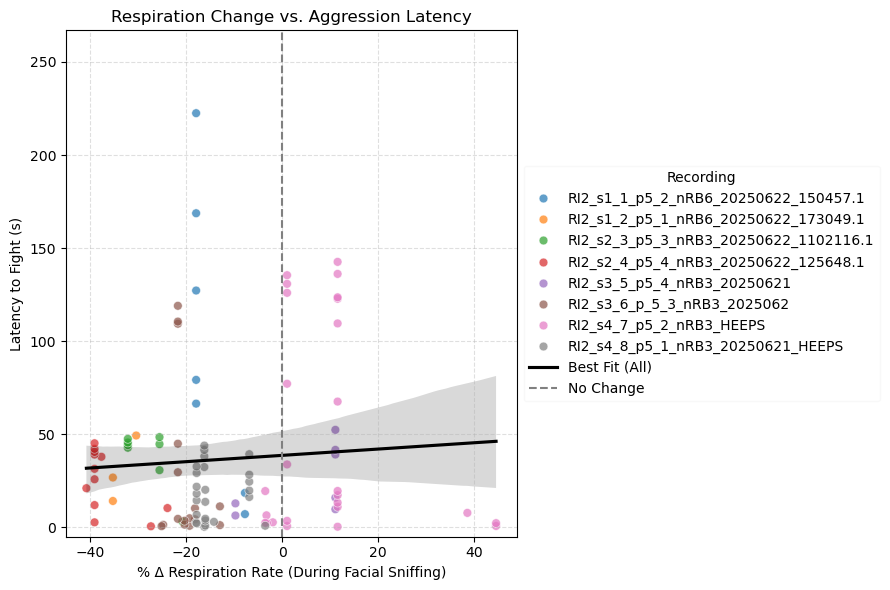

In [1128]:
min_latency = -5
max_latency = RI2_facial_agent_behavior_df["latency"].max()
buffer = max(5, max_latency * 0.2)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=RI2_facial_agent_behavior_df,
    x="%Resp Rate Change",
    y="latency",
    hue="recording",  # Change if your label is different
    palette="tab10",
    alpha=0.7,
    s=40
)
sns.regplot(
    data=RI2_facial_agent_behavior_df,
    x="%Resp Rate Change",
    y="latency",
    scatter=False,
    color="black",
    label="Best Fit (All)"
)
plt.axvline(0, linestyle='--', color='gray', label='No Change')
plt.xlabel("% Δ Respiration Rate (During Facial Sniffing)")
plt.ylabel("Latency to Fight (s)")
plt.title("Respiration Change vs. Aggression Latency")
plt.ylim(min_latency, max_latency + buffer)
plt.grid(True, linestyle='--', alpha=0.4)
leg = plt.legend(title="Recording", fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))
leg.get_frame().set_alpha(0.12)
plt.tight_layout()
plt.show()


In [1129]:
print(RI2_facial_agent_behavior_df["recording"].value_counts())


recording
RI2_s4_7_p5_2_nRB3_HEEPS                 26
RI2_s4_8_p5_1_nRB3_20250621_HEEPS        25
RI2_s3_6_p_5_3_nRB3_2025062              16
RI2_s2_4_p5_4_nRB3_20250622_125648.1     12
RI2_s2_3_p5_3_nRB3_20250622_1102116.1     8
RI2_s1_1_p5_2_nRB6_20250622_150457.1      7
RI2_s3_5_p5_4_nRB3_20250621               7
RI2_s1_2_p5_1_nRB6_20250622_173049.1      3
Name: count, dtype: int64


In [1130]:
RI2_body_agent_behavior_df = RI2_agent_behavior_df[RI2_agent_behavior_df['from_behavior'] == 'body sniffing']

In [1131]:
# filter out latencies less than 0.3 seconds
RI2_body_agent_behavior_df = RI2_body_agent_behavior_df[RI2_body_agent_behavior_df['latency'] >= 0.3]

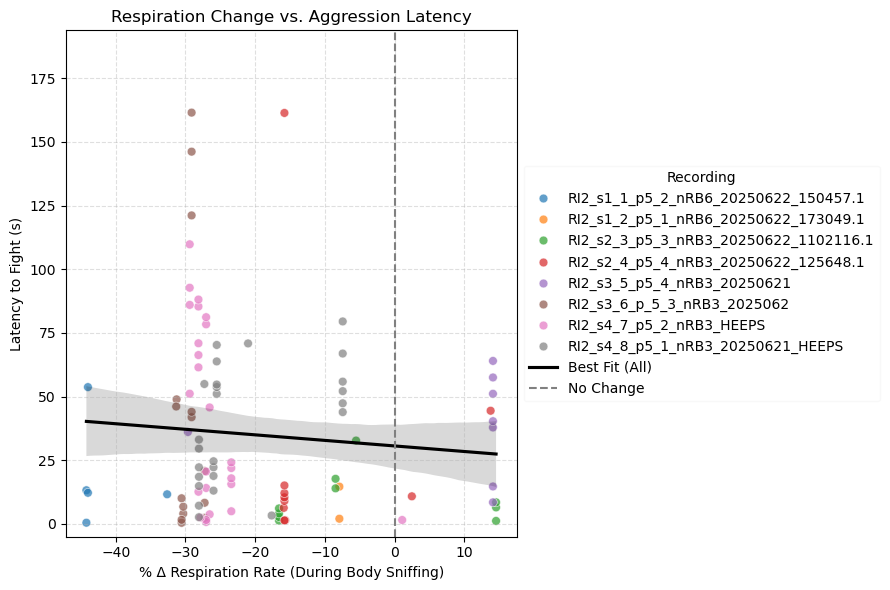

In [1132]:
min_latency = -5
max_latency = RI2_body_agent_behavior_df["latency"].max()
buffer = max(5, max_latency * 0.2)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=RI2_body_agent_behavior_df,
    x="%Resp Rate Change",
    y="latency",
    hue="recording",  # Change if your label is different
    palette="tab10",
    alpha=0.7,
    s=40
)
sns.regplot(
    data=RI2_body_agent_behavior_df,
    x="%Resp Rate Change",
    y="latency",
    scatter=False,
    color="black",
    label="Best Fit (All)"
)
plt.axvline(0, linestyle='--', color='gray', label='No Change')
plt.xlabel("% Δ Respiration Rate (During Body Sniffing)")
plt.ylabel("Latency to Fight (s)")
plt.title("Respiration Change vs. Aggression Latency")
plt.ylim(min_latency, max_latency + buffer)
plt.grid(True, linestyle='--', alpha=0.4)
leg = plt.legend(title="Recording", fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))
leg.get_frame().set_alpha(0.12)
plt.tight_layout()
plt.show()


In [1133]:
print(RI2_body_agent_behavior_df["recording"].value_counts())


recording
RI2_s4_7_p5_2_nRB3_HEEPS                 25
RI2_s4_8_p5_1_nRB3_20250621_HEEPS        25
RI2_s3_6_p_5_3_nRB3_2025062              15
RI2_s2_3_p5_3_nRB3_20250622_1102116.1    10
RI2_s2_4_p5_4_nRB3_20250622_125648.1     10
RI2_s3_5_p5_4_nRB3_20250621               8
RI2_s1_1_p5_2_nRB6_20250622_150457.1      5
RI2_s1_2_p5_1_nRB6_20250622_173049.1      2
Name: count, dtype: int64


In [1134]:
RI2_anogenital_agent_behavior_df = RI2_agent_behavior_df[RI2_agent_behavior_df['from_behavior'] == 'anogenital sniffing']

In [1135]:
# filter out latencies less than 0.3 seconds
RI2_anogenital_agent_behavior_df = RI2_anogenital_agent_behavior_df[RI2_anogenital_agent_behavior_df['latency'] >= 0.3]

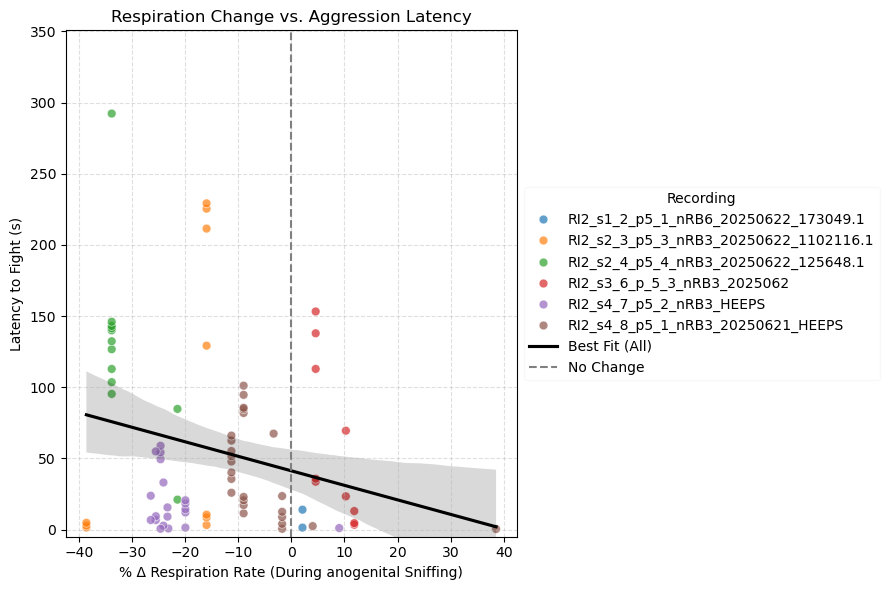

In [1136]:
min_latency = -5
max_latency = RI2_anogenital_agent_behavior_df["latency"].max()
buffer = max(5, max_latency * 0.2)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=RI2_anogenital_agent_behavior_df,
    x="%Resp Rate Change",
    y="latency",
    hue="recording",  # Change if your label is different
    palette="tab10",
    alpha=0.7,
    s=40
)
sns.regplot(
    data=RI2_anogenital_agent_behavior_df,
    x="%Resp Rate Change",
    y="latency",
    scatter=False,
    color="black",
    label="Best Fit (All)"
)
plt.axvline(0, linestyle='--', color='gray', label='No Change')
plt.xlabel("% Δ Respiration Rate (During anogenital Sniffing)")
plt.ylabel("Latency to Fight (s)")
plt.title("Respiration Change vs. Aggression Latency")
plt.ylim(min_latency, max_latency + buffer)
plt.grid(True, linestyle='--', alpha=0.4)
leg = plt.legend(title="Recording", fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))
leg.get_frame().set_alpha(0.12)
plt.tight_layout()
plt.show()


In [1137]:
print(RI2_anogenital_agent_behavior_df["recording"].value_counts())


recording
RI2_s4_8_p5_1_nRB3_20250621_HEEPS        25
RI2_s4_7_p5_2_nRB3_HEEPS                 20
RI2_s2_4_p5_4_nRB3_20250622_125648.1     12
RI2_s2_3_p5_3_nRB3_20250622_1102116.1    10
RI2_s3_6_p_5_3_nRB3_2025062              10
RI2_s1_2_p5_1_nRB6_20250622_173049.1      2
Name: count, dtype: int64
